### Clinical Data Studies Dataset

Looking into the optimisation of treatment for different age groups with BP

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [24]:
raw_clinics = pd.read_csv(r"C:\Users\Rebecca\Desktop\Python Projects\GitHub - Clinical Data Study\Bells Palsy Clinical Trial.csv")
display(raw_clinics.head())

,Patient ID,Sex,Age,Baseline Score on House–Brackmann scale,Time between onset of symptoms and start of treatment,Treatment Group,Received Prednisolone,Received Acyclovir,3-Month Score on House–Brackmann scale,Full Recovery in 3 Months,9-Month Score on House–Brackmann scale,Full Recovery in 9 Months
0,1,Female,77,6,Within 24 hr,Prednisolone–Placebo,Yes,No,2,No,2,No
1,2,Female,61,6,Within 24 hr,Prednisolone–Placebo,Yes,No,1,Yes,1,Yes
2,3,Female,46,4,>24 to ≤48 hr,Prednisolone–Placebo,Yes,No,1,Yes,1,Yes
3,4,Female,46,3,Within 24 hr,Prednisolone–Placebo,Yes,No,1,Yes,1,Yes
4,5,Female,42,3,>24 to ≤48 hr,Prednisolone–Placebo,Yes,No,1,Yes,1,Yes


In [32]:
raw_clinics.isna().sum() 
#No N/A or Missing values

Patient ID                                               0
Sex                                                      0
Age                                                      0
Baseline Score on House–Brackmann scale                  0
Time between onset of symptoms and start of treatment    0
Treatment Group                                          0
Received Prednisolone                                    0
Received Acyclovir                                       0
3-Month Score on House–Brackmann scale                   0
Full Recovery in 3 Months                                0
9-Month Score on House–Brackmann scale                   0
Full Recovery in 9 Months                                0
dtype: int64

In [39]:
### EDA (Exploratory Data Analysis)

In [41]:
clinics = raw_clinics.rename(columns={
    'Baseline Score on House–Brackmann scale': 'Baseline_Score',
    'Time between onset of symptoms and start of treatment': 'Time_to_Treatment',
    'Treatment Group': 'Treatment_Group',
    'Received Prednisolone': 'Prednisolone',
    'Received Acyclovir': 'Acyclovir',
    'Full Recovery in 9 Months': 'Recovery_9M'
})

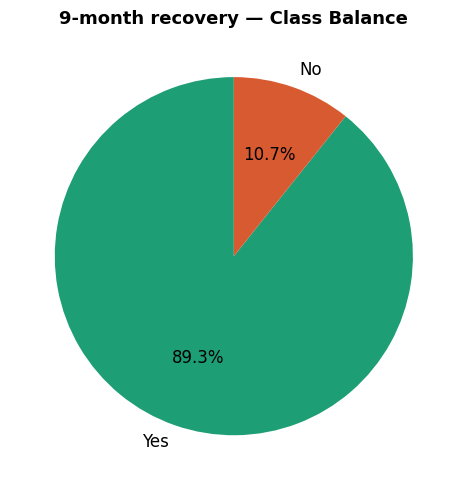

In [45]:
counts = clinics['Recovery_9M'].value_counts()
fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    counts,                          # the numbers to plot
    labels=counts.index,             # 'Yes' / 'No' as slice labels
    colors=['#1D9E75', '#D85A30'],   # green for recovered, orange for not
    autopct='%1.1f%%',              # show percentage on each slice
    startangle=90,                   # rotate so 'Yes' starts at the top
    textprops={'fontsize': 12}
)

ax.set_title('9-month recovery — Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

This measure is misleading, it is a dummy classifier, and ignores all features; predicting only the majority class each time. It would score 89% accuracy on a dataset, but will nto tell us specifics about a particular patient. The classes are imbalanced, which means accuracy is misleading.

Recovered: 441 patients, mean age 43.8
Not recovered: 53 patients, mean age 53.6


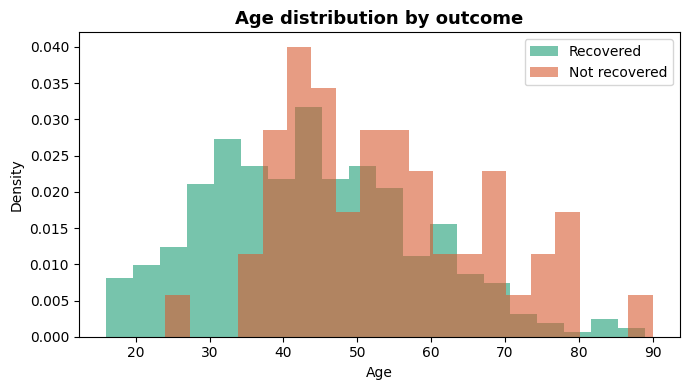

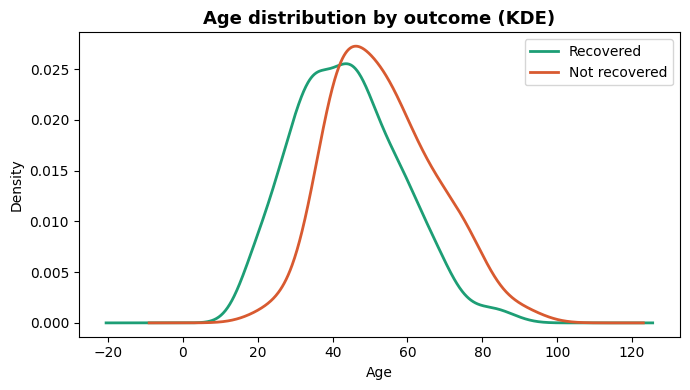

In [49]:
recovered    = clinics[clinics['Recovery_9M'] == 'Yes']
unrecovered  = clinics[clinics['Recovery_9M'] == 'No']

print(f"Recovered: {len(recovered)} patients, mean age {recovered['Age'].mean():.1f}")
print(f"Not recovered: {len(unrecovered)} patients, mean age {unrecovered['Age'].mean():.1f}")

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(recovered['Age'],    bins=20, color='#1D9E75', alpha=0.6, label='Recovered',     density=True)
ax.hist(unrecovered['Age'],  bins=20, color='#D85A30', alpha=0.6, label='Not recovered', density=True)

ax.set_title('Age distribution by outcome', fontsize=13, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

recovered['Age'].plot.kde(ax=ax, color='#1D9E75', linewidth=2, label='Recovered')
unrecovered['Age'].plot.kde(ax=ax, color='#D85A30', linewidth=2, label='Not recovered')

ax.set_title('Age distribution by outcome (KDE)', fontsize=13, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

In [50]:
treatment_rate = clinics.groupby('Treatment_Group')['Recovery_9M'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values()

print(treatment_rate)

Treatment_Group
Acyclovir–Placebo         84.426230
Placebo–Placebo           85.245902
Acyclovir–Prednisolone    92.913386
Prednisolone–Placebo      94.308943
Name: Recovery_9M, dtype: float64


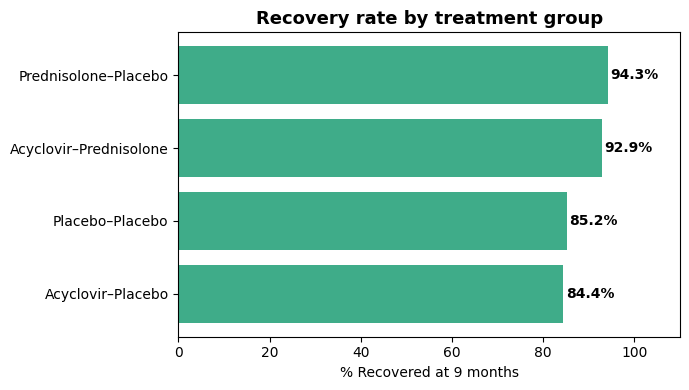

In [51]:
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.barh(
    treatment_rate.index,   # group names on the y-axis
    treatment_rate.values,  # recovery % on the x-axis
    color='#1D9E75',
    alpha=0.85
)

# Add the percentage as a label at the end of each bar
for bar, val in zip(bars, treatment_rate.values):
    ax.text(
        bar.get_width() + 0.5,                    # x position — just past the bar end
        bar.get_y() + bar.get_height() / 2,       # y position — middle of the bar
        f'{val:.1f}%',                             # the label text
        va='center', fontsize=10, fontweight='bold'
    )

ax.set_title('Recovery rate by treatment group', fontsize=13, fontweight='bold')
ax.set_xlabel('% Recovered at 9 months')
ax.set_xlim(0, 110)   # leave room for the labels on the right
plt.tight_layout()
plt.show()

Acyclovir is probably going to come out as a low-importance feature. The model will learn that it doesn't move the needle. Prednisolone, on the other hand, should rank highly. This is useful — when your feature importance results come back later, you can sanity check them against what the EDA already told you. If the model said Acyclovir was the most important feature, that would be a red flag.

Baseline_Score
2    94.047619
3    92.592593
4    88.957055
5    87.341772
6    69.696970
Name: Recovery_9M, dtype: float64
Baseline_Score
2     84
3    135
4    163
5     79
6     33
Name: count, dtype: int64


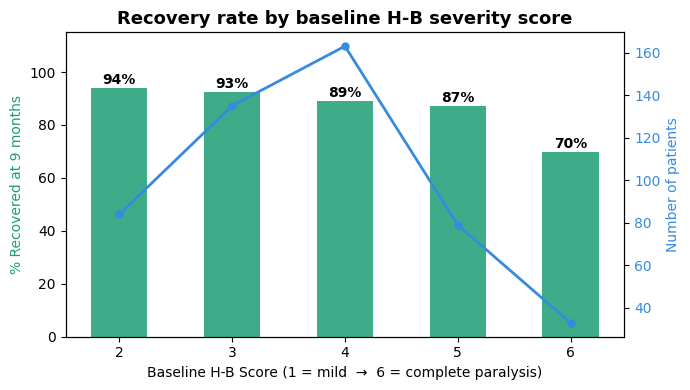

In [54]:
recovery_by_score = clinics.groupby('Baseline_Score')['Recovery_9M'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

# Also get the count per score so you know how many patients are behind each bar
counts_by_score = clinics['Baseline_Score'].value_counts().sort_index()

print(recovery_by_score)
print(counts_by_score)
fig, ax1 = plt.subplots(figsize=(7, 4))

# -- Primary axis: recovery rate bars --
bars = ax1.bar(
    recovery_by_score.index,
    recovery_by_score.values,
    color='#1D9E75',
    alpha=0.85,
    width=0.5,
    zorder=2
)

# Add percentage labels above each bar
for bar, val in zip(bars, recovery_by_score.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{val:.0f}%',
        ha='center', fontsize=10, fontweight='bold'
    )

ax1.set_xlabel('Baseline H-B Score (1 = mild  →  6 = complete paralysis)')
ax1.set_ylabel('% Recovered at 9 months', color='#1D9E75')
ax1.set_ylim(0, 115)
ax1.set_xticks([1, 2, 3, 4, 5, 6])

# -- Secondary axis: patient counts as a line --
ax2 = ax1.twinx()
ax2.plot(
    counts_by_score.index,
    counts_by_score.values,
    color='#378ADD',
    linewidth=2,
    marker='o',
    markersize=5,
    label='Patient count'
)
ax2.set_ylabel('Number of patients', color='#378ADD')
ax2.tick_params(axis='y', labelcolor='#378ADD')

ax1.set_title('Recovery rate by baseline H-B severity score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The model will see very few examples of score 1 and score 6 patients during training, which means it won't learn their patterns as reliably. If someone presented with a score of 6 in production, my model's prediction for them would be less confident than for a score 3 or 4 patient — even if it doesn't explicitly tell you that.

Pre-processing <br>
1. Dropping columns we won't use 
2. Encoding categorical columns ('Y'/'N')
3. Scaling numerical columns

In [68]:
# Columns measured AFTER the trial started — the model can't know these at prediction time
clinics_df = clinics.drop(columns=[
    'Patient ID',               # just an identifier, no predictive value
    '3-Month Score on House–Brackmann scale',   # measured after baseline
    'Full Recovery in 3 Months',               # measured after baseline
    '9-Month Score on House–Brackmann scale'   # this IS your target, don't use as a feature
])

# Separate features (X) from target (y)
X = clinics_df.drop(columns=['Recovery_9M'])
y = clinics_df['Recovery_9M']

print(X.columns.tolist())
print(y.value_counts())

y = (y == 'Yes').astype(int)
print(y.value_counts())

time_map = {
    'Within 24 hr':   0,
    '>24 to ≤48 hr':  1,
    '>48 to ≤72 hr':  2,
    'Unknown':        3
}
X['Time_to_Treatment'] = (
    X['Time_to_Treatment'].map(time_map)
)
X = pd.get_dummies(X, columns=[
    'Sex',
    'Treatment_Group',
    'Prednisolone',
    'Acyclovir'
], drop_first=True)

print(X.head())
print(X.dtypes)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[['Age', 'Baseline_Score']] = scaler.fit_transform(X[['Age', 'Baseline_Score']])

print(X[['Age', 'Baseline_Score']].describe())

['Sex', 'Age', 'Baseline_Score', 'Time_to_Treatment', 'Treatment_Group', 'Prednisolone', 'Acyclovir']
Recovery_9M
Yes    441
No      53
Name: count, dtype: int64
Recovery_9M
1    441
0     53
Name: count, dtype: int64
   Age  Baseline_Score  Time_to_Treatment  Sex_Male  \
0   77               6                  0     False   
1   61               6                  0     False   
2   46               4                  1     False   
3   46               3                  0     False   
4   42               3                  1     False   

   Treatment_Group_Acyclovir–Prednisolone  Treatment_Group_Placebo–Placebo  \
0                                   False                            False   
1                                   False                            False   
2                                   False                            False   
3                                   False                            False   
4                                   False                    

In [69]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print()
print("Any remaining non-numeric columns:")
print(X.select_dtypes(exclude='number').columns.tolist())
print()
print("Any missing values:")
print(X.isnull().sum().sum())
print()
print("Target balance:")
print(y.value_counts())
print()
print("First 3 rows:")
print(X.head(3))

Feature matrix shape: (494, 9)
Target shape: (494,)

Any remaining non-numeric columns:
['Sex_Male', 'Treatment_Group_Acyclovir–Prednisolone', 'Treatment_Group_Placebo–Placebo', 'Treatment_Group_Prednisolone–Placebo', 'Prednisolone_Yes', 'Acyclovir_Yes']

Any missing values:
0

Target balance:
Recovery_9M
1    441
0     53
Name: count, dtype: int64

First 3 rows:
        Age  Baseline_Score  Time_to_Treatment  Sex_Male  \
0  2.210540        2.051853                  0     False   
1  1.109796        2.051853                  0     False   
2  0.077849        0.282891                  1     False   

   Treatment_Group_Acyclovir–Prednisolone  Treatment_Group_Placebo–Placebo  \
0                                   False                            False   
1                                   False                            False   
2                                   False                            False   

   Treatment_Group_Prednisolone–Placebo  Prednisolone_Yes  Acyclovir_Yes  
0    

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)
print(f"Training set:  {X_train.shape[0]} patients")
print(f"Test set:      {X_test.shape[0]} patients")
print()
print("Training target balance:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Test target balance:")
print(y_test.value_counts(normalize=True).round(3))

Training set:  395 patients
Test set:      99 patients

Training target balance:
Recovery_9M
1    0.894
0    0.106
Name: proportion, dtype: float64

Test target balance:
Recovery_9M
1    0.889
0    0.111
Name: proportion, dtype: float64


In [73]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',  # compensates for the 89/11 imbalance
    random_state=42,
    max_iter=1000             # gives the solver enough steps to converge
)

model.fit(X_train, y_train)
print("Model trained.")
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of recovery for each patient
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Not recovered', 'Recovered']))

print("=== ROC-AUC Score ===")
print(f"{roc_auc_score(y_test, y_prob):.3f}")

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

Model trained.
=== Classification Report ===
               precision    recall  f1-score   support

Not recovered       0.18      0.64      0.28        11
    Recovered       0.93      0.64      0.76        88

     accuracy                           0.64        99
    macro avg       0.56      0.64      0.52        99
 weighted avg       0.85      0.64      0.70        99

=== ROC-AUC Score ===
0.653
=== Confusion Matrix ===
[[ 7  4]
 [32 56]]


The confusion matrix tells us a lot; <br>
1. Correctly predicted 7 non-recoveries, 4 were predicted as recoveries
2. 56 correctly predcted recoveries, 32 were predicted as non-recoveries
The last one is the most painful, using class_weight = 'balanced' overshot the model and makes it more aggressive at catching the minority class. <br>

The model only predicts with an 18% precision that a patient won't recover which isn't great. <br>

The logistic regression did not work well here, the features do not seperate cleanly enough for a linear boundary to work well. This is why we will move onto a Random Forest, it handes non-linear relationships way better! 


Instead of one decision boundary like logistic regression, a Random Forest builds hundreds of decision trees, each trained on a slightly different random subset of your data and features. Each tree votes on the outcome, and the majority vote wins.
The "random" part is deliberate — by training each tree on different data and features, the trees make different mistakes. When you average across all of them, the mistakes cancel out and the signal strengthens. This is called ensemble learning.

Random Forest trained.
=== Classification Report ===
               precision    recall  f1-score   support

Not recovered       0.21      0.55      0.30        11
    Recovered       0.93      0.74      0.82        88

     accuracy                           0.72        99
    macro avg       0.57      0.64      0.56        99
 weighted avg       0.85      0.72      0.76        99

=== ROC-AUC Score ===
0.655
=== Confusion Matrix ===
[[ 6  5]
 [23 65]]


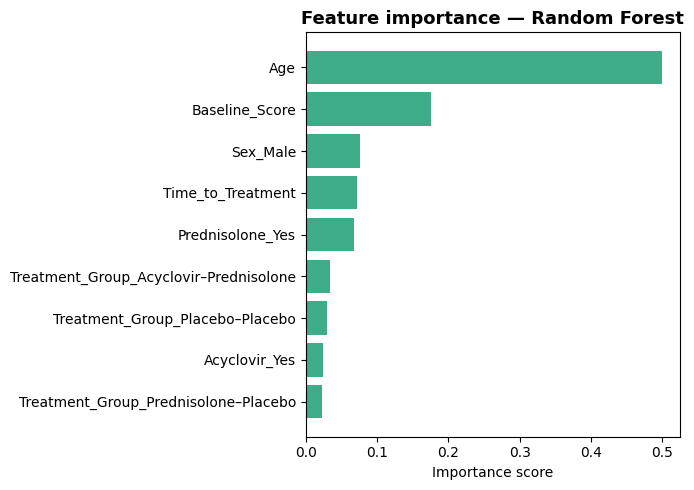

In [76]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,       # number of trees — more is generally better up to a point
    class_weight='balanced', # same imbalance fix as before
    random_state=42,
    max_depth=6,            # limits how deep each tree can grow — prevents overfitting
    min_samples_leaf=5      # each leaf must have at least 5 patients — prevents overfitting
)

rf_model.fit(X_train, y_train)
print("Random Forest trained.")

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, rf_pred, target_names=['Not recovered', 'Recovered']))

print("=== ROC-AUC Score ===")
print(f"{roc_auc_score(y_test, rf_prob):.3f}")

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, rf_pred))

importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(importances.index, importances.values, color='#1D9E75', alpha=0.85)
ax.set_title('Feature importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

The Random Forest Classifier performs better than the logistic regression. However our results still aren't quite precise enough to call it a good predicting model. Both models are seemingly uncertain about separating two classes at a fundamental level. The Random Forest is making better predictions, but the underlying separability of your data is the limiting factor, not the algorithm.

Since both models did not work well enough, I am going to try some cross-validation and hyperparameter tuning to see if we can get this model to predict at a more precise level.

In [77]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    rf_model, X, y,
    cv=cv,
    scoring=['roc_auc', 'f1_macro', 'recall_macro'],
    return_train_score=True
)

print("=== Cross-validation results (current Random Forest) ===")
print(f"ROC-AUC:      {scores['test_roc_auc'].mean():.3f}  ±  {scores['test_roc_auc'].std():.3f}")
print(f"F1 macro:     {scores['test_f1_macro'].mean():.3f}  ±  {scores['test_f1_macro'].std():.3f}")
print(f"Recall macro: {scores['test_recall_macro'].mean():.3f}  ±  {scores['test_recall_macro'].std():.3f}")
print()
print("Individual fold ROC-AUC scores:")
for i, score in enumerate(scores['test_roc_auc'], 1):
    print(f"  Fold {i}: {score:.3f}")

=== Cross-validation results (current Random Forest) ===
ROC-AUC:      0.671  ±  0.030
F1 macro:     0.551  ±  0.020
Recall macro: 0.594  ±  0.046

Individual fold ROC-AUC scores:
  Fold 1: 0.666
  Fold 2: 0.683
  Fold 3: 0.707
  Fold 4: 0.681
  Fold 5: 0.617


In [79]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':     [100, 200, 300, 500, 700],
    'max_depth':        [3, 4, 5, 6, 8, None],       # None = unlimited depth
    'min_samples_leaf': [1, 2, 3, 5, 8, 10],
    'min_samples_split':[2, 5, 10, 15],               # min patients to split a node
    'max_features':     ['sqrt', 'log2', 0.5]         # features considered at each split
}
search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=param_grid,
    n_iter=50,              # try 50 random combinations
    scoring='roc_auc',      # optimise for ROC-AUC
    cv=cv,                  # use the same StratifiedKFold as before
    random_state=42,
    n_jobs=-1,              # use all CPU cores — speeds things up
    verbose=1
)

search.fit(X_train, y_train)

print("=== Best parameters ===")
print(search.best_params_)
print()
print(f"Best cross-validated ROC-AUC: {search.best_score_:.3f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
=== Best parameters ===
{'n_estimators': 300, 'min_samples_split': 15, 'min_samples_leaf': 3, 'max_features': 0.5, 'max_depth': 3}

Best cross-validated ROC-AUC: 0.691


In [81]:
best_model = search.best_estimator_

tuned_scores = cross_validate(
    best_model, X, y,
    cv=cv,
    scoring=['roc_auc', 'f1_macro', 'recall_macro']
)

print("=== Tuned model cross-validation ===")
print(f"ROC-AUC:      {tuned_scores['test_roc_auc'].mean():.3f}  ±  {tuned_scores['test_roc_auc'].std():.3f}")
print(f"F1 macro:     {tuned_scores['test_f1_macro'].mean():.3f}  ±  {tuned_scores['test_f1_macro'].std():.3f}")
print(f"Recall macro: {tuned_scores['test_recall_macro'].mean():.3f}  ±  {tuned_scores['test_recall_macro'].std():.3f}")

print(search.best_params_)

=== Tuned model cross-validation ===
ROC-AUC:      0.694  ±  0.049
F1 macro:     0.545  ±  0.050
Recall macro: 0.641  ±  0.053
{'n_estimators': 300, 'min_samples_split': 15, 'min_samples_leaf': 3, 'max_features': 0.5, 'max_depth': 3}


c:\Users\Rebecca\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\Rebecca\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


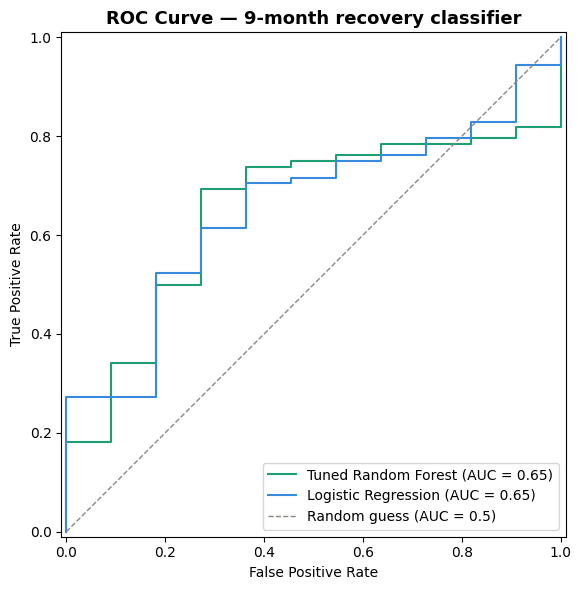

In [82]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 6))

# Plot the tuned model's ROC curve
RocCurveDisplay.from_estimator(
    best_model, X_test, y_test,
    ax=ax,
    color='#1D9E75',
    name='Tuned Random Forest'
)

# Plot the logistic regression for comparison
RocCurveDisplay.from_estimator(
    model, X_test, y_test,
    ax=ax,
    color='#378ADD',
    name='Logistic Regression'
)

# Plot the diagonal — this is what random guessing looks like
ax.plot([0, 1], [0, 1], color='#888780', linestyle='--', linewidth=1, label='Random guess (AUC = 0.5)')

ax.set_title('ROC Curve — 9-month recovery classifier', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [83]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Final predictions on the held-out test set
final_pred = best_model.predict(X_test)
final_prob = best_model.predict_proba(X_test)[:, 1]

print("=== Final Model — Test Set Evaluation ===")
print()
print(classification_report(y_test, final_pred, target_names=['Not recovered', 'Recovered']))
print(f"ROC-AUC: {roc_auc_score(y_test, final_prob):.3f}")
print()
print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, final_pred)
print(cm)
print()
print(f"True Negatives  (correctly flagged as won't recover): {cm[0,0]}")
print(f"False Negatives (missed — predicted recover, actually didn't): {cm[0,1]}")
print(f"False Positives (overcautious — predicted won't recover, actually did): {cm[1,0]}")
print(f"True Positives  (correctly identified as recovered): {cm[1,1]}")

=== Final Model — Test Set Evaluation ===

               precision    recall  f1-score   support

Not recovered       0.20      0.73      0.31        11
    Recovered       0.95      0.64      0.76        88

     accuracy                           0.65        99
    macro avg       0.57      0.68      0.54        99
 weighted avg       0.87      0.65      0.71        99

ROC-AUC: 0.650

=== Confusion Matrix ===
[[ 8  3]
 [32 56]]

True Negatives  (correctly flagged as won't recover): 8
False Negatives (missed — predicted recover, actually didn't): 3
False Positives (overcautious — predicted won't recover, actually did): 32
True Positives  (correctly identified as recovered): 56


In [89]:
# Start from a blank row with all columns set to 0
new_patient = pd.DataFrame(0, index=[0], columns=X_train.columns)

# Then fill in just the values for your fictional patient
new_patient['Age'] = 65
new_patient['Baseline_Score'] = 5
new_patient['Time_to_Treatment'] = 0        # Within 24hr
new_patient['Sex_Male'] = 1
new_patient['Treatment_Group_Prednisolone–Placebo'] = 1
new_patient['Prednisolone_Yes'] = 1

# Scale age and baseline score
new_patient[['Age', 'Baseline_Score']] = scaler.transform(
    new_patient[['Age', 'Baseline_Score']]
)

prob = best_model.predict_proba(new_patient)[0, 1]
pred = best_model.predict(new_patient)[0]

print(f"Predicted outcome:        {'Recovered' if pred == 1 else 'Not recovered'}")
print(f"Probability of recovery:  {prob:.1%}")

Predicted outcome:        Not recovered
Probability of recovery:  46.9%


Our model was not the most accurate predictor, I would pin this to the fact we have a small dataset <500, and additionally, the models could not reasonably linearly seperate the features, and even non-linearly to a modest degree, the ROC-AUC is a good observation of this. With only 53 non-recoverers, we were working with a small subset of data which meant the model had very few examples of the minority class to learn from. As a rule, most models need hundreds of observations per class to work with. 
The simulated patient gave us a good insight into the model, and also compares well to the EDA earlier. We see that he is in an older age category, and he has a high baseline score, which are two valuable predictors in the model. Along with the EDA, I would conclude the model performed to a reasonable evaluation of this patient.